In [ ]:
# Reverse transcription (RT) stop analysis of the four bases PRADA-MaP seq --- --- 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from statannot import add_stat_annotation 
from Bio import SeqIO
from sklearn import metrics 

In [ ]:
## 1. Extend Figure 7e-7f --- --- 
### 1_1. Extend Fig7e --- --- 
### 1_2. Extend Fig7f --- --- 

In [ ]:
### 1_1. Extend Fig5e --- --- 

In [2]:
#### input data --- 

output = './Data/'
rtbd = pd.read_csv(output+"PRADA_RTstop_reactivity.csv",index_col=0)

flt = rtbd[['tid', 'pos', 'base','sample', 'Label_RT', 'Ctrl_RT']]
flt.columns

tmp1 = flt[['tid', 'pos', 'base', 'sample', 'Label_RT']]
tmp1.columns = ['tid', 'pos', 'base', 'sample', 'RT']
tmp1['group'] = 'Label'

tmp2 = flt[['tid', 'pos', 'base', 'sample', 'Ctrl_RT']]
tmp2.columns = ['tid', 'pos', 'base', 'sample', 'RT']
tmp2['group'] = 'Ctrl'

fltt = pd.concat([tmp1,tmp2], ignore_index=True)
fltt['id'] = fltt['sample'] +':' +fltt['group']

fltt['id'].mask(fltt['id'] == 'HEK-MTS_s4U_1:Label', 'HEK-MTS_s4U_Label_1', inplace=True)
fltt['id'].mask(fltt['id'] == 'HEK-MTS_s4U_2:Label', 'HEK-MTS_s4U_Label_2', inplace=True)
fltt['id'].mask(fltt['id'] == 'HEK-MTS_s4U_1:Ctrl', 'HEK-MTS_s4U_Ctrl_1', inplace=True)
fltt['id'].mask(fltt['id'] == 'HEK-MTS_s4U_2:Ctrl', 'HEK-MTS_s4U_Ctrl_2', inplace=True)
fltt['base'] = np.where(fltt['base'] == 'T', 'U', fltt['base'])

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

G_Label v.s. G_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.206e-03 U_stat=5.336e+05
U_Label v.s. U_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=7.991e-09 U_stat=1.368e+06
A_Label v.s. A_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.837e-07 U_stat=1.100e+06
C_Label v.s. C_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.134e-08 U_stat=1.144e+06
U_Label v.s. G_Label: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.928e-02 U_stat=8.227e+05
U_Label v.s. A_Label: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.000e+00 U_stat=1.105e+06
U_Label v.s. C_Label: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.000e+00 U_stat=1.086e+06


/tmp/ipykernel_13583/2446911576.py:36: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  print(dplot.groupby(['base','group']).median()[['RT']])


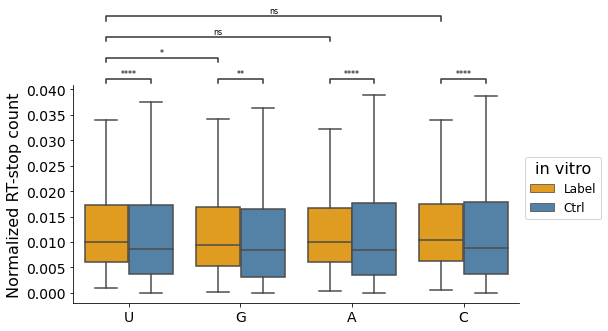

In [3]:
#### plot --- 

dplot = fltt
dplot.to_csv('./Data/'+'source_data_Efig7e.csv',sep=',')

plt.figure(figsize=(8,4))

order = ['U','G', 'A',  'C']
my_pal = {'Label': "orange", 'Ctrl': "steelblue"}

ax = sns.boxplot(data=dplot, x='base',y='RT', hue='group',showfliers = False,order = order, palette = my_pal)     
plt.title(' ',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Normalized RT-stop count',fontsize = 16)
plt.xticks(fontsize = 14) 
plt.yticks(fontsize = 14) 
legend=plt.legend(loc='best', title='in vitro',bbox_to_anchor=(1.00, 0.7),prop={'size': 12})
legend.get_title().set_fontsize('16') 
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data=dplot, x='base',y='RT', hue='group', order=order, 
                    box_pairs = [(("U", 'Label'), ("U", 'Ctrl')),
                                 (("A", 'Label'), ("A", 'Ctrl')),
                                 (("C", 'Label'), ("C", 'Ctrl')),
                                 (("G", 'Label'), ("G", 'Ctrl')),

                                 (("U", 'Label'), ("G", 'Label')),
                                 (("U", 'Label'), ("A", 'Label')),
                                 (("U", 'Label'), ("C", 'Label'))
                                ],
                    test="Mann-Whitney", text_format='star', loc='outside', line_offset_to_box=0.01, verbose=1,fontsize=8)  

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig7e_PRADA_RTstop_label_vs_Ctrl.pdf',bbox_inches='tight', dpi=300) 

print(dplot.groupby(['base','group']).median()[['RT']])  

In [4]:
print(dplot.groupby(['base','group']).mean()[['RT']])  

                  RT
base group          
A    Ctrl   0.015867
     Label  0.016542
C    Ctrl   0.013351
     Label  0.014323
G    Ctrl   0.012457
     Label  0.013548
U    Ctrl   0.013632
     Label  0.014674


/tmp/ipykernel_15397/1194782632.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  print(dplot.groupby(['base','group']).mean()[['RT']])


In [5]:
print(dplot.groupby(["base", "group"]).count())  

             tid   pos  sample    RT    id
base group                                
A    Ctrl   1402  1402    1402  1402  1402
     Label  1402  1402    1402  1402  1402
C    Ctrl   1424  1424    1424  1424  1424
     Label  1424  1424    1424  1424  1424
G    Ctrl    986   986     986   986   986
     Label   986   986     986   986   986
U    Ctrl   1559  1559    1559  1559  1559
     Label  1559  1559    1559  1559  1559


In [ ]:
### 1_2. Extend Fig5f --- --- --- --- 

In [ ]:
#### SS vs DS regions 

In [4]:
def convert_dot(input_file,rna): 
    sequences=[i for i in SeqIO.parse(open(input_file),'fasta')] 
    
    seq_0 = str(sequences[0].seq)
    length = len(seq_0)
    base = seq_0[0:int(length/2)]
    dot = seq_0[int(length/2):int(length)]
    
    base = list(map(lambda i:i, base))
    dot = list(map(lambda i:i, dot))
    strand = list(map(lambda i: 1 if i == "." else 0, dot))
    Nucleotide = range(1,len(strand)+1)
    
    bench = pd.DataFrame(list(zip(base,dot,strand,Nucleotide)),
              columns=['base','dot','strand','Position2'])
    bench.to_csv('./Data/'+rna+'_base_dot_strand.csv',sep='\t')
    
    return bench 

In [5]:
def plot_SS_DS_regions(dotfile,transcript1,transcript2):

    ### A. get the benchmarker 

    dir_bench = './Data/bench/'
    bench = convert_dot(dir_bench+dotfile,transcript1)
    bench.head(50)
    bench['pos'] = bench['Position2']

    ### B. get the mito gid, tid 

    dir = './Data/'
    mitoall = pd.read_csv(dir+'mitoall_transcripts_ids.txt',sep='\t')
    mitoall.columns
    mitoall.columns = ['tid', 'g_id', 'g_name', 'g_biotype', 't_name', 't_biotype']

    flt = mitoall[mitoall['g_name'] == transcript2]
    tid=list(flt.tid)[0]
    print(tid) 

    ### C. get the RT stop data 
    
    output = './Data/'
    rtbd = pd.read_csv(output+"PRADA_RTstop_reactivity.csv",index_col=0)

    trans = rtbd[(rtbd['tid'] == tid)]

    ### D. merge RT files and bench 

    merge = pd.merge(trans,bench, how='left', on=['pos','pos']) 

    ### E. prepare the file for plotting 

    dplot=merge
    tmp1 = dplot[dplot['strand'] == 1]
    tmp1['region'] = 'SS'
    tmp2 = dplot[dplot['strand'] == 0]
    tmp2['region'] = 'DS'
    dplot = pd.concat([tmp1,tmp2], ignore_index=True)
    dplott = dplot[(dplot['base_x'] =='T')]
    
    dplott.to_csv('./Data/'+'source_data_Efig7f.csv',sep=',')
    
    ### F. plot the boxplot for SS and DS regions 
    
    plt.figure(figsize=(2,4))
    order = ['SS', 'DS']
    
    ax = sns.boxplot(data=dplott, x='region',y='shape', showfliers = False,order = order, dodge = False) 
    plt.title(transcript1,fontsize = 18)
    plt.xlabel('',fontsize = 16) 
    plt.ylabel('Base U \n Normalized reactivity',fontsize = 16)
    plt.xticks(fontsize = 14,rotation=90) 
    plt.yticks(fontsize = 14) 
    plt.legend(loc='best', bbox_to_anchor=(1.01, 0.7),prop={'size': 12})
    ax.spines[['right', 'top']].set_visible(False) 

    add_stat_annotation(ax, data = dplott, x = dplott['region'], y = dplott['shape'], order=order, 
                        box_pairs = [('SS','DS')
                                    ],
                        test="Mann-Whitney", text_format='full', loc='inside', line_offset_to_box=0.1, verbose=3)  #line_offset_to_box=-0.001,

    dir_out = './Data/'
    plt.savefig(dir_out+'Extend_Fig7f_PRADA_RTstop_SS_vs_DS.pdf',bbox_inches='tight', dpi=300) 

    print(dplott.groupby(["region"]).count())  

/tmp/ipykernel_13583/3195001040.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp1['region'] = 'SS'
/tmp/ipykernel_13583/3195001040.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp2['region'] = 'DS'
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ENST00000362079
SS v.s. DS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=3.074e-02 U_stat=7.505e+02
        tid  pos  base_x  n_rt  n_bd  d_rt  d_bd  shape  win_num  sample  \
region                                                                     
DS       18   18      18    18    18    18    18     18       18      18   
SS      122  122     122   122   122   122   122    122      122     122   

        Label_RT  Ctrl_RT  reac_raw  base_y  dot  strand  Position2  
region                                                               
DS            18       18        18      18   18      18         18  
SS           122      122       122     122  122     122        122  


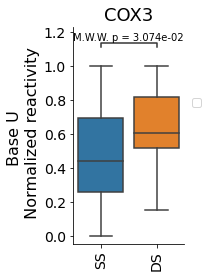

In [6]:
plot_SS_DS_regions('bench_positive_COX3_1_786_79.dot','COX3','MT-CO3')

In [ ]:
#### AUROC COX3 --- --- 

In [7]:
def plot_AUROC(dotfile,transcript1,transcript2):

    ### A. get the benchmarker 
    
    dir_bench = './Data/bench/'
    bench = convert_dot(dir_bench+dotfile,transcript1)
    bench.head(50)
    bench['pos'] = bench['Position2']

    ### B. get the mito gid, tid 

    dir = './Data/'
    mitoall = pd.read_csv(dir+'mitoall_transcripts_ids.txt',sep='\t')
    mitoall.columns
    mitoall.columns = ['tid', 'g_id', 'g_name', 'g_biotype', 't_name', 't_biotype']

    flt = mitoall[mitoall['g_name'] == transcript2]
    tid=list(flt.tid)[0]
    print(tid) 

    ### C. get the RT stop data 
    
    output = './Data/'
    rtbd = pd.read_csv(output+"PRADA_RTstop_reactivity.csv",index_col=0)
    trans = rtbd[(rtbd['tid'] == tid)]

    ### D. merge RT files and bench 

    merge = pd.merge(trans,bench, how='left', on=['pos','pos']) 

    ### E. prepare the file for plotting 

    dplot=merge
    tmp1 = dplot[dplot['strand'] == 1]
    tmp1['region'] = 'SS'
    tmp2 = dplot[dplot['strand'] == 0]
    tmp2['region'] = 'DS'
    dplot = pd.concat([tmp1,tmp2], ignore_index=True)
    dplott = dplot[(dplot['base_x'] =='T') | (dplot['base_x'] =='G')]
    dplott['norm_react'] = dplott['shape']

    dplott.to_csv('./Data/'+'source_data_Efig7f_auroc.csv',sep=',')

    ### F. plot the AUROC 
    
    fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(dplott.strand, dplott.norm_react, pos_label=1)
    roc_auc_1 = metrics.auc(fpr_1, tpr_1)
    print(roc_auc_1)
        
    fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
        ax.tick_params(width = 2)
        
    plt.title(transcript1+'\n (UG '+str(dplott.shape[0])+' positions)', fontsize = 25)
    plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)
    plt.legend(loc = 'lower right', fontsize = 18)
    plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate', fontsize = 20)
    plt.xlabel('False Positive Rate', fontsize = 20)
    plt.xticks(fontsize = 18)
    plt.yticks(fontsize = 18)
    
    dir_out = './Data/'
    plt.savefig(dir_out+'Extend_Fig7f_PRADA_RTstop_COX3_AUROC.pdf',bbox_inches='tight', dpi=300) 

ENST00000362079
0.48145695364238406


/tmp/ipykernel_13583/68137436.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp1['region'] = 'SS'
/tmp/ipykernel_13583/68137436.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp2['region'] = 'DS'
/tmp/ipykernel_13583/68137436.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returnin

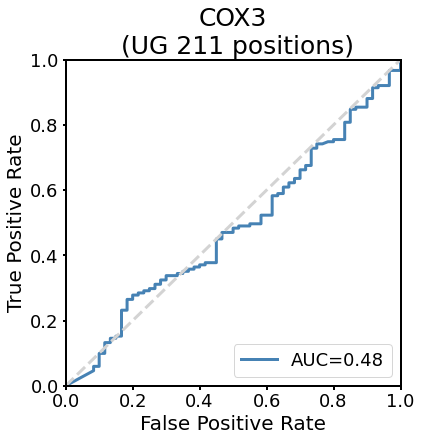

In [8]:
plot_AUROC('bench_positive_COX3_1_786_79.dot','COX3','MT-CO3')